# Multiclass classification with different methods

**Objective:** In this notebook, we present three approaches to solving a multiclass classification problem: logistic regression, decision trees, and random forests. The example is based on the seaborn penguins dataset.

**Author:** Dr. Juan Manuel Ahuactzin Larios

In [1]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import plot_tree

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.inspection import DecisionBoundaryDisplay

# 1 Visualization Utilities

### Define a plotting function to display the results

In [2]:
def plot_classification_results(model, predictors_data, all_data, predictor_columns, target_column):
    # Create a palette with 10 colors, but only use the first 3 colors for the 3 classes in the target column
    tab10_norm = mpl.colors.Normalize(vmin=-0.5, vmax=8.5)

    # Select colors for each class in the order of the unique values in the target column
    palette = ["tab:blue", "tab:orange", "tab:green"] 

    # Plot the decision boundary
    dbd = DecisionBoundaryDisplay.from_estimator(
        model,
        predictors_data,
        response_method="predict",
        cmap="tab10",
        norm=tab10_norm,
        alpha=0.5,
    )

    # Plot the training data points on top of the decision boundary
    sns.scatterplot(
        data=all_data,
        x=predictor_columns[0],
        y=predictor_columns[1],
        hue=target_column,
        palette=palette,
    )

    # put the legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    _ = plt.title("Decision boundary using a logistic regression")

# 2 Data Loading and Preparation


<div style="
    height:500px;
    width:100%;
    border:2px solid lightgray;
    padding:10px;
    padding:15px;
    border-radius:8px;
    box-sizing:border-box;
">

### Upload the dataset file

<div style="text-align:center;">
    <img src="../images/penguin.png" style="height:400px; width:auto;">
</div>
</div>

In [3]:
penguins = sns.load_dataset("penguins")
penguins.dropna(inplace=True)
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


### Define the predictor variables and the target variable

In [4]:
predictor_columns = ["bill_length_mm", "bill_depth_mm"]
target_column = "species"
print(f"Species: {penguins[target_column].unique()}")

Species: ['Adelie' 'Chinstrap' 'Gentoo']


### Split the data into training and test sets

In [5]:
data, target = penguins[predictor_columns], penguins[target_column]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=42
)

# 3 Model Training and Evaluation

## Logistic regresion

### Construct and fit the logistic regression model

In [6]:
linear_model = LogisticRegression()
linear_model.fit(data_train, target_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Plot the classification results of the logistic regression model on the training data

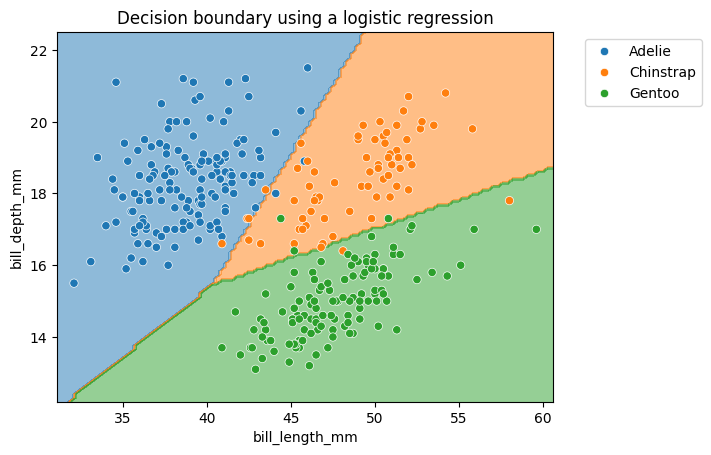

In [7]:
plot_classification_results(linear_model, data_train, penguins, predictor_columns, target_column)

### Print the accuracy of the logistic regression model on the test data

In [8]:
test_score = linear_model.score(data_test, target_test)
print(f"Accuracy of the LogisticRegression: {test_score:.2f}")

Accuracy of the LogisticRegression: 0.95


## Decision tree

### Train a Decision Tree Classifier

In [9]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(data_train, target_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Plot the classification results of the decision tree model on the training data

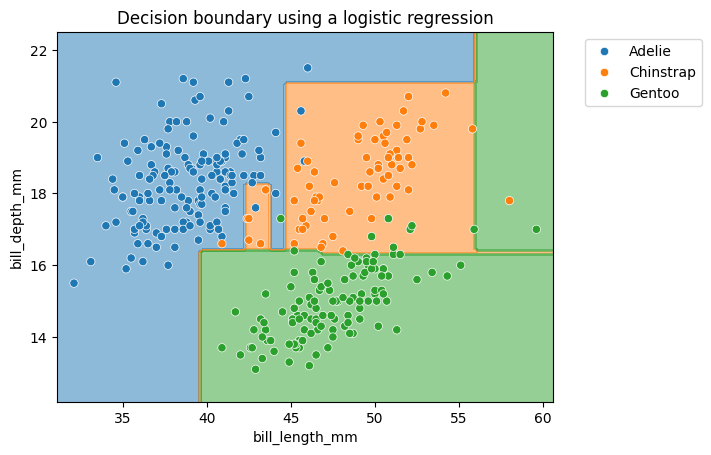

In [10]:
plot_classification_results(tree_model, data_train, penguins, predictor_columns, target_column)

### Print the accuracy of the decision tree model on the test data

In [11]:
test_score = tree_model.score(data_test, target_test)
print(f"Accuracy of the Decision Tree: {test_score:.2f}")

Accuracy of the Decision Tree: 0.89


### Display the decision tree

Each node contains the following information:

- `flipper_length <= 16.45`: Decision rule. If the condition is True, the sample goes to the left child; otherwise, it goes to the right child.
- `samples = 249`: Number of training samples that reach this node.
- `value = [106, 53, 90]`: Distribution of samples across the classes at this node.
- `class = Adelie`: Predicted class, corresponding to the class with the highest frequency.

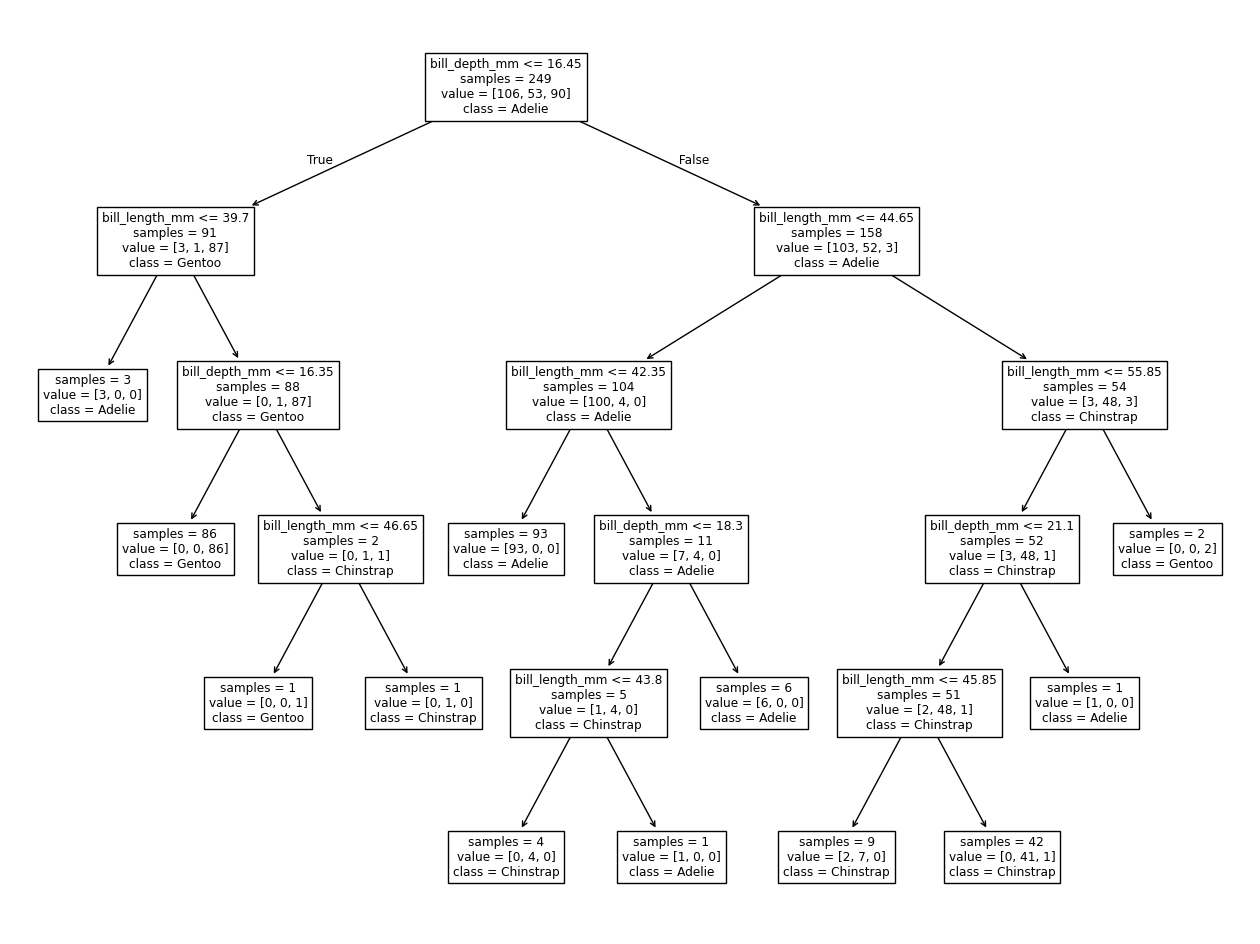

In [12]:
_, ax = plt.subplots(figsize=(16, 12))
_ = plot_tree(
    tree_model,
    feature_names=predictor_columns,
    class_names=tree_model.classes_.tolist(),
    impurity=False,
    ax=ax,
)

## Random forest

### Train a random forest model

In [13]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(data_train, target_train, )

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Plot the classification results of the random forest model on the training data

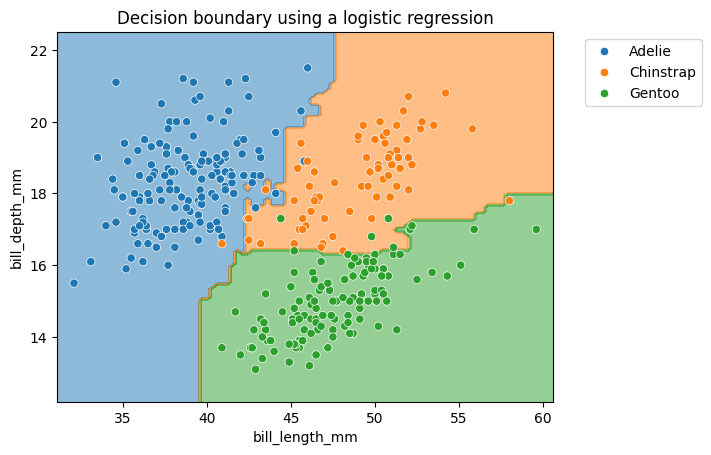

In [14]:
plot_classification_results(rf_model, data_train, penguins, predictor_columns, target_column)

### Print the accuracy of the random forest model on the test data

In [15]:
test_score = rf_model.score(data_test, target_test)
print(f"Accuracy of the Random Forest: {test_score:.2f}")

Accuracy of the Random Forest: 0.92
